In [1]:
#carga inicial de librerias
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
ruta = '/content/drive/MyDrive/Data/'

In [4]:
ruta = '/content/drive/MyDrive/Data/'

# Dataset de Kaggle
df_kaggle = pd.read_csv(ruta + 'tv_shows.csv')

# Dataset de IMDb
df_imdb = pd.read_csv(
    ruta + 'title.basics.tsv',
    sep='\t',
    na_values='\\N',
    low_memory=False,
    dtype={'startYear': 'Int64', 'endYear': 'Int64', 'runtimeMinutes': 'string'}
)

print("IMDb:", df_imdb.shape)
df_imdb.head()

IMDb: (12446144, 9)


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,<NA>,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,<NA>,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,<NA>,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,<NA>,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,<NA>,1,Short


In [5]:
# Quedarnos solo con series
df_series = df_imdb[df_imdb['titleType'].isin(['tvSeries', 'tvMiniSeries'])].copy()
print("Series IMDb:", df_series.shape)
print("Datos Kaggle \n" )
df_kaggle.columns.tolist()

Series IMDb: (367842, 9)
Datos Kaggle 



['Unnamed: 0',
 'ID',
 'Title',
 'Year',
 'Age',
 'IMDb',
 'Rotten Tomatoes',
 'Netflix',
 'Hulu',
 'Prime Video',
 'Disney+',
 'Type']

In [6]:
# Normalizar para un mejor match
df_kaggle['title_clean'] = df_kaggle['Title'].str.lower().str.strip()
df_series['title_clean'] = df_series['primaryTitle'].str.lower().str.strip()

# Año como entero en ambos (ajusta 'Year' si se llama distinto en tu dataset)
df_kaggle['Year'] = pd.to_numeric(df_kaggle['Year'], errors='coerce').astype('Int64')

# Merge por título y año (reduce falsos positivos de series con mismo nombre)
df_merged = df_kaggle.merge(
    df_series[['title_clean', 'startYear', 'genres', 'tconst']],
    left_on=['title_clean', 'Year'],
    right_on=['title_clean', 'startYear'],
    how='left'
)

print("Filas tras merge:", df_merged.shape)
print("Con género asignado:", df_merged['genres'].notna().sum())
print("Sin match:", df_merged['genres'].isna().sum())

Filas tras merge: (5467, 16)
Con género asignado: 4011
Sin match: 1456


In [7]:
plataformas = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

df_long = df_merged.melt(
    id_vars=['Title', 'Year', 'genres', 'tconst'],
    value_vars=plataformas,
    var_name='Platform',
    value_name='Available'
)

# Nos quedamos solo con las combinaciones donde la serie SÍ está en la plataforma
df_long = df_long[df_long['Available'] == 1].copy()
print("Filas serie-plataforma:", df_long.shape)

Filas serie-plataforma: (5885, 6)


In [8]:
# Eliminar filas sin género antes de expandir
df_long = df_long.dropna(subset=['genres']).copy()

df_long['genres_list'] = df_long['genres'].str.split(',')
df_exploded = df_long.explode('genres_list').rename(columns={'genres_list': 'Genre'})

print("Filas serie-plataforma-género:", df_exploded.shape)
df_exploded.head()

Filas serie-plataforma-género: (9627, 7)


,Title,Year,genres,tconst,Platform,Available,Genre
0,Breaking Bad,2008,"Crime,Drama,Thriller",tt0903747,Netflix,1,Crime
0,Breaking Bad,2008,"Crime,Drama,Thriller",tt0903747,Netflix,1,Drama
0,Breaking Bad,2008,"Crime,Drama,Thriller",tt0903747,Netflix,1,Thriller
1,Stranger Things,2016,"Drama,Fantasy,Horror",tt4574334,Netflix,1,Drama
1,Stranger Things,2016,"Drama,Fantasy,Horror",tt4574334,Netflix,1,Fantasy


In [9]:
# Géneros más comunes en general
df_exploded['Genre'].value_counts().head(15)

# Series por plataforma
df_exploded.drop_duplicates(['Title', 'Platform'])['Platform'].value_counts()

# Tabla cruzada: conteo de series por plataforma y género
tabla = df_exploded.pivot_table(
    index='Genre', columns='Platform',
    values='Title', aggfunc='nunique', fill_value=0
)
tabla = tabla.sort_values(by='Netflix', ascending=False).head(15)
tabla

Platform,Disney+,Hulu,Netflix,Prime Video
Genre,,,,
Drama,39,447,763,388
Comedy,107,456,490,282
Animation,102,294,307,176
Crime,2,160,289,143
Action,65,242,280,142
Adventure,113,200,260,157
Documentary,66,111,239,228
Romance,1,103,185,57
Reality-TV,24,199,131,133


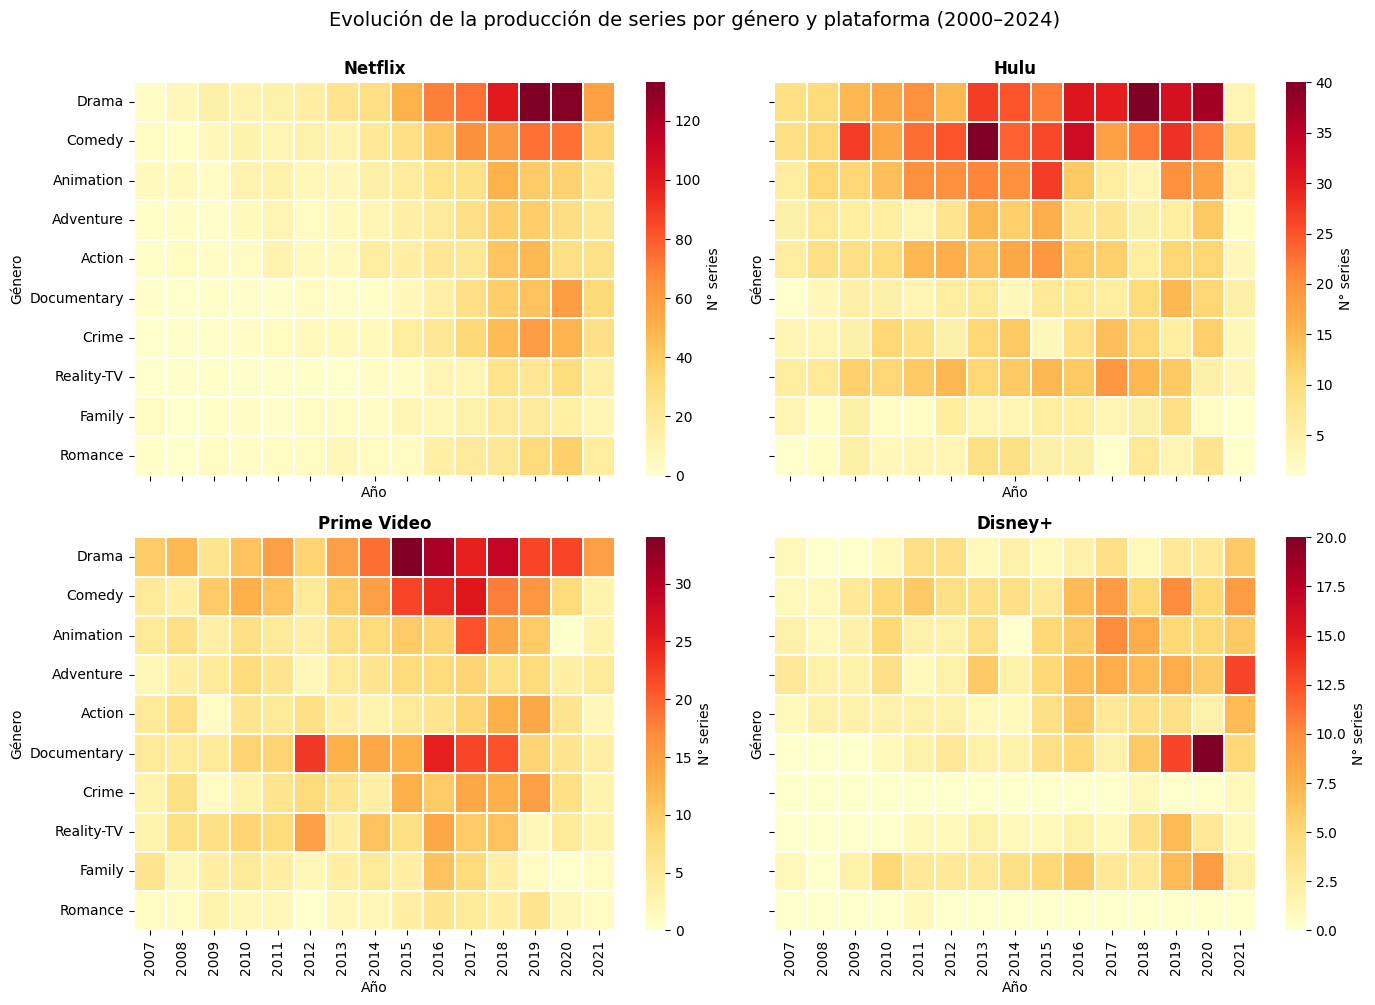

In [10]:


# Preparar datos
top_generos = df_exploded['Genre'].value_counts().head(10).index
df_plot = df_exploded[df_exploded['Genre'].isin(top_generos)].copy()
df_plot = df_plot.dropna(subset=['Year'])
df_plot['Year'] = df_plot['Year'].astype(int)
df_plot = df_plot[(df_plot['Year'] >= 2007) & (df_plot['Year'] <= 2024)]

# Crear un heatmap por plataforma
plataformas = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, plat in enumerate(plataformas):
    sub = df_plot[df_plot['Platform'] == plat]
    pivot = sub.pivot_table(index='Genre', columns='Year',
                            values='Title', aggfunc='nunique', fill_value=0)
    pivot = pivot.reindex(top_generos)  # mismo orden en todos los paneles
    sns.heatmap(pivot, cmap='YlOrRd', ax=axes[i],
                cbar_kws={'label': 'N° series'}, linewidths=0.2)
    axes[i].set_title(plat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel('Género')

fig.suptitle('Evolución de la producción de series por género y plataforma (2000–2024)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('heatmap_generos_plataforma_anio.png', dpi=300, bbox_inches='tight')
plt.show()

#Parte Grupal



In [27]:
import plotly.express as px

agregado = df_long.groupby(['Platform', 'Genre']).agg(
    count=('Title', 'nunique'),
    diff_promedio=('Diff_CA', 'mean'),
    imdb_promedio=('IMDb_num', 'mean'),
    rt_promedio=('RT_num', 'mean')
).reset_index()

fig = px.treemap(
    agregado,
    path=['Platform', 'Genre'],
    values='count',
    color='diff_promedio',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    hover_data={'imdb_promedio': ':.2f', 'rt_promedio': ':.2f', 'count': True},
    title='Composición del catálogo y recepción por plataforma y género'
)
fig.update_layout(height=700, margin=dict(t=60, l=20, r=20, b=20))
fig.show()

fig.write_html('treemap_grupal.html')
